<a href="https://colab.research.google.com/github/Anusha-Borole/Credit-Card-Fraud-Detection/blob/main/BTP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mounting Google Drive & Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = "/content/drive/MyDrive/Data/creditcardtask.csv.zip"
df = pd.read_csv(file_path)

df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Preprocessing

In [ ]:
print("Missing Values:\n", df.isnull().sum().sum())

print("\nClass Distribution:\n", df["Class"].value_counts())

df["Class"] = df["Class"].astype("category")

X = df.drop(columns=["Class"])
y = df["Class"]


Missing Values:
 0

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


## Exploratory Data Analysis (EDA) with Visualizations

<ipython-input-12-f4339f08d6c0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=["blue", "red"])


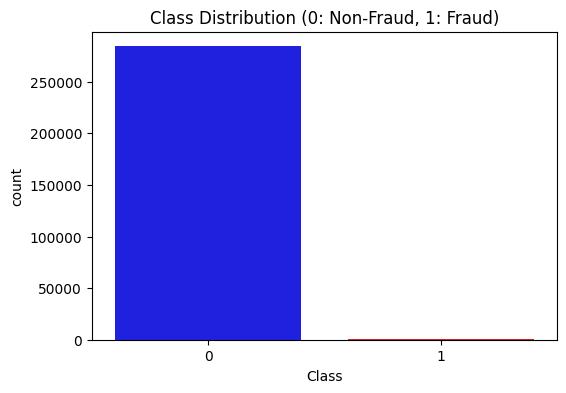

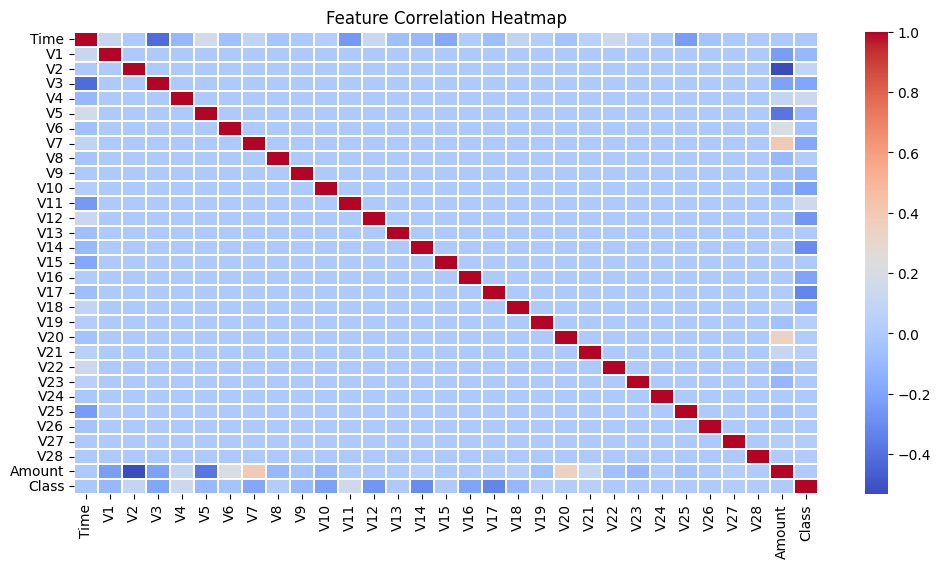

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette=["blue", "red"])
plt.title("Class Distribution (0: Non-Fraud, 1: Fraud)")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.1)
plt.title("Feature Correlation Heatmap")
plt.show()


## Train-Test Split & Data Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardizing features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Define evaluation function
def evaluate_model(name, y_test, preds):
    print(f"\n Model: {name}\n")
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("\nClassification Report:\n", classification_report(y_test, preds))

# Optimized Random Forest
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# Optimized XGBoost with faster tree method
xgb_model = XGBClassifier(tree_method="hist", use_label_encoder=False, eval_metric='logloss')

# Use a subset of training data for faster debugging (Optional)
X_train_sample, _, y_train_sample, _ = train_test_split(X_train_scaled, y_train, train_size=0.3, random_state=42)

# Train models
rf_model.fit(X_train_sample, y_train_sample)
xgb_model.fit(X_train_sample, y_train_sample)

# Predictions
rf_preds = rf_model.predict(X_test_scaled)
xgb_preds = xgb_model.predict(X_test_scaled)

# Evaluate models
evaluate_model("Random Forest (Optimized)", y_test, rf_preds)
evaluate_model("XGBoost (Optimized)", y_test, xgb_preds)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:10:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📊 Model: Random Forest (Optimized)

Confusion Matrix:
 [[56849    15]
 [   20    78]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.80      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962


📊 Model: XGBoost (Optimized)

Confusion Matrix:
 [[56857     7]
 [   21    77]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



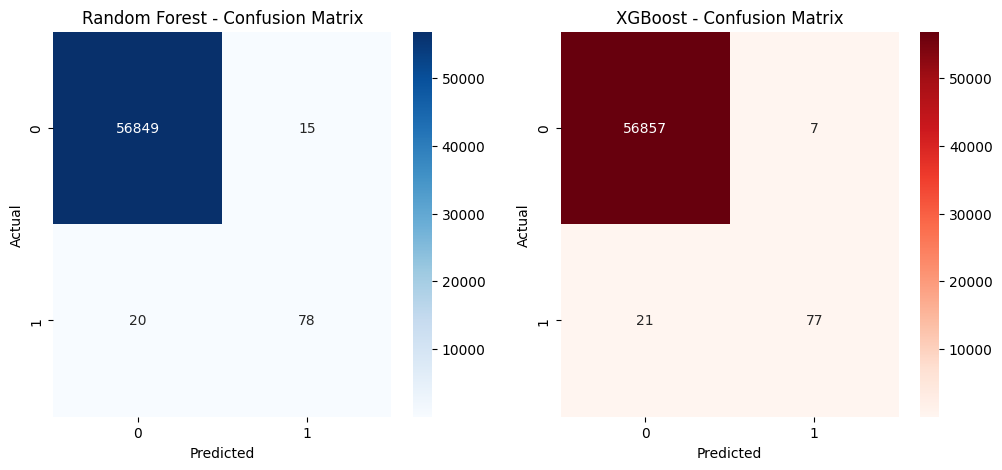

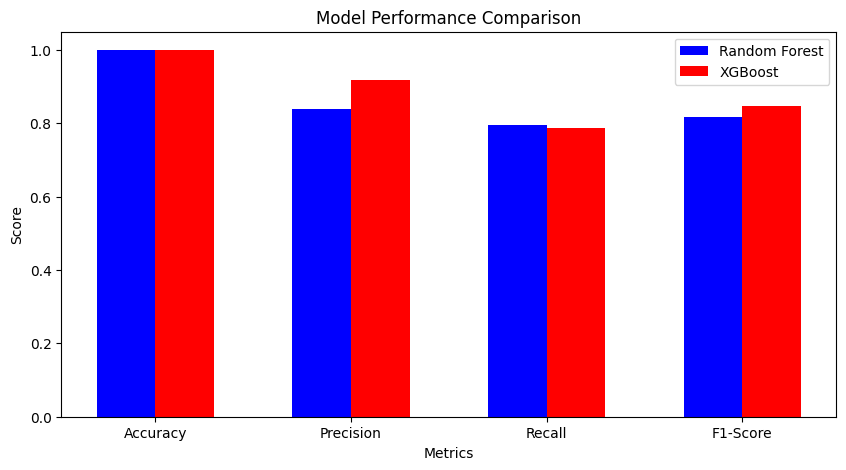

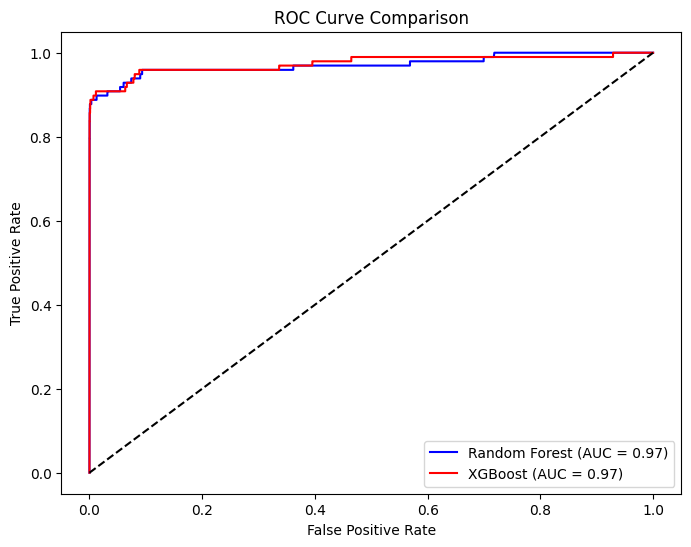

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Collect performance metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

rf_scores = [
    accuracy_score(y_test, rf_preds),
    precision_score(y_test, rf_preds),
    recall_score(y_test, rf_preds),
    f1_score(y_test, rf_preds)
]

xgb_scores = [
    accuracy_score(y_test, xgb_preds),
    precision_score(y_test, xgb_preds),
    recall_score(y_test, xgb_preds),
    f1_score(y_test, xgb_preds)
]

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RF Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap="Blues", ax=axes[0])
axes[0].set_title("Random Forest - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# XGBoost Confusion Matrix
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d', cmap="Reds", ax=axes[1])
axes[1].set_title("XGBoost - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.show()

# Bar Chart Comparing Classification Metrics
x = range(len(metrics))

plt.figure(figsize=(10, 5))
plt.bar(x, rf_scores, width=0.3, label="Random Forest", color="blue")
plt.bar([i + 0.3 for i in x], xgb_scores, width=0.3, label="XGBoost", color="red")

plt.xticks([i + 0.15 for i in x], metrics)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

# ROC Curve for Both Models
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_model.predict_proba(X_test_scaled)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {auc(rf_fpr, rf_tpr):.2f})", color="blue")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {auc(xgb_fpr, xgb_tpr):.2f})", color="red")
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()
